In [ ]:
import os, random, numpy as np, pandas as pd, torch
from tqdm import tqdm
import nltk
from nltk.tokenize import sent_tokenize
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.optim import AdamW


# File Paths
LABELED_CSV         = "labeled_sentences_1.csv"
SPEECHES_CSV        = "bsp_speech_dataset.csv"
SAVE_MODEL_DIR      = "finetuned_roberta_bsp_sent"
OUT_DIR             = "out_roberta"

# Column Names
TEXT_COL_LABELED    = "sentence"
LABEL_COL_LABELED   = "label"                 # must be in {negative, neutral, positive}
TEXT_COL_SPEECHES   = "Text"
ID_COL_SPEECHES     = "index"
DATE_COL_SPEECHES   = "Date"

# Training Hyperparams
BASE_MODEL          = "roberta-base"
MAX_LENGTH_TRAIN    = 256
BATCH_SIZE_TRAIN    = 16
EPOCHS              = 5
LR                  = 2e-5
WEIGHT_DECAY        = 0.01
WARMUP_STEPS        = 0
SEED                = 42

# Scoring Hyperparams
MAX_LENGTH_SCORE    = 512
BATCH_SIZE_SCORE    = 32

# Dixed Sentiment Label Order
LABEL_ORDER = ["negative", "neutral", "positive"]  # required

# Setup
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

try: nltk.data.find("tokenizers/punkt")
except LookupError: nltk.download("punkt")
try: nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    try: nltk.download("punkt_tab")
    except: pass

device = "cuda" if torch.cuda.is_available() else "cpu"
device

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


'cuda'

In [ ]:
# Load labeled sentences
df_lab = pd.read_csv(LABELED_CSV).dropna(subset=[TEXT_COL_LABELED, LABEL_COL_LABELED]).copy()

# Validate labels are exactly negative/neutral/positive (any case accepted)
df_lab[LABEL_COL_LABELED] = df_lab[LABEL_COL_LABELED].str.lower().str.strip()
unknown = set(df_lab[LABEL_COL_LABELED].unique()) - set(LABEL_ORDER)
if unknown:
    raise ValueError(f"Found unknown labels {unknown}. Labels must be exactly {LABEL_ORDER}.")

label2id = {lab:i for i, lab in enumerate(LABEL_ORDER)}
id2label = {v:k for k,v in label2id.items()}

df_lab["label_id"] = df_lab[LABEL_COL_LABELED].map(label2id)

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df_lab, test_size=0.2, random_state=SEED, stratify=df_lab["label_id"]
)

len(train_df), len(val_df), train_df[LABEL_COL_LABELED].value_counts()


(3640,
 910,
 label
 positive    1734
 neutral     1646
 negative     260
 Name: count, dtype: int64)

In [ ]:
tok = AutoTokenizer.from_pretrained(BASE_MODEL)

class SentDataset(Dataset):
    def __init__(self, df, text_col, label_col_id, tokenizer, max_length):
        self.texts = df[text_col].tolist()
        self.labels = df[label_col_id].astype(int).tolist()
        self.tok = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            truncation=True, max_length=self.max_length, padding=False,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k,v in enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

def collate_fn_factory(tokenizer):
    def collate_fn(batch):
        keys = batch[0].keys()
        to_pad = {k: [b[k] for b in batch] for k in keys}
        return tokenizer.pad(to_pad, padding=True, return_tensors="pt")
    return collate_fn

train_ds = SentDataset(train_df, TEXT_COL_LABELED, "label_id", tok, MAX_LENGTH_TRAIN)
val_ds   = SentDataset(val_df,   TEXT_COL_LABELED, "label_id", tok, MAX_LENGTH_TRAIN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True,  collate_fn=collate_fn_factory(tok))
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE_TRAIN, shuffle=False, collate_fn=collate_fn_factory(tok))

len(train_dl), len(val_dl)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

(228, 57)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABEL_ORDER),
    id2label=id2label,
    label2id=label2id,
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

num_training_steps = EPOCHS * len(train_dl)

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=num_training_steps
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def metrics_from_preds(preds, labels, num_labels):
    preds = np.asarray(preds); labels = np.asarray(labels)
    acc = (preds == labels).mean() if len(labels) else 0.0
    f1s = []
    for c in range(num_labels):
        tp = np.sum((preds==c) & (labels==c))
        fp = np.sum((preds==c) & (labels!=c))
        fn = np.sum((preds!=c) & (labels==c))
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        f1s.append(f1)
    return {"accuracy": float(acc), "f1_macro": float(np.mean(f1s))}

best_f1 = -1.0

for ep in range(1, EPOCHS+1):
    # Train
    model.train()
    tr_loss = 0.0
    for batch in tqdm(train_dl, desc=f"Epoch {ep}/{EPOCHS} - train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        loss = loss_fn(out.logits, batch["labels"])
        loss.backward()
        tr_loss += loss.item()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    tr_loss /= max(1, len(train_dl))

    # Validate
    model.eval()
    val_loss = 0.0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f"Epoch {ep}/{EPOCHS} - val"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = loss_fn(out.logits, batch["labels"])
            val_loss += loss.item()
            preds = out.logits.argmax(dim=-1).cpu().numpy().tolist()
            lbls  = batch["labels"].cpu().numpy().tolist()
            preds_all.extend(preds); labels_all.extend(lbls)
    val_loss /= max(1, len(val_dl))
    m = metrics_from_preds(preds_all, labels_all, len(LABEL_ORDER))
    print(f"Epoch {ep:02d} | train_loss {tr_loss:.4f} | val_loss {val_loss:.4f} | "
          f"acc {m['accuracy']:.3f} | f1_macro {m['f1_macro']:.3f}")

    # Save best
    if m["f1_macro"] > best_f1:
        best_f1 = m["f1_macro"]
        model.save_pretrained(SAVE_MODEL_DIR)
        tok.save_pretrained(SAVE_MODEL_DIR)
        with open(os.path.join(SAVE_MODEL_DIR, "labels.txt"), "w") as f:
            for lab in LABEL_ORDER: f.write(lab + "\n")
        print(f"  ↳ Saved best to {SAVE_MODEL_DIR} (f1_macro={best_f1:.3f})")


Epoch 1/5 - val: 100%|██████████| 57/57 [00:03<00:00, 17.27it/s]

Epoch 01 | train_loss 0.7281 | val_loss 0.5388 | acc 0.754 | f1_macro 0.750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ↳ Saved best to finetuned_roberta_bsp_sent (f1_macro=0.750)


Epoch 2/5 - val: 100%|██████████| 57/57 [00:03<00:00, 16.69it/s]


...

Epoch 04 | train_loss 0.2522 | val_loss 0.6808 | acc 0.745 | f1_macro 0.738


Epoch 5/5 - val: 100%|██████████| 57/57 [00:03<00:00, 16.11it/s]

Epoch 05 | train_loss 0.1599 | val_loss 0.7029 | acc 0.760 | f1_macro 0.755


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ↳ Saved best to finetuned_roberta_bsp_sent (f1_macro=0.755)


In [ ]:
# Load fine-tuned model
clf_tok = AutoTokenizer.from_pretrained(SAVE_MODEL_DIR)
clf_mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_MODEL_DIR).to(device).eval()

def softmax_np(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=-1, keepdims=True)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating best saved RoBERTa model: 100%|██████████| 57/57 [00:03<00:00, 16.99it/s]


Label order used:
['negative', 'neutral', 'positive']

Model id2label:
{0: 'negative', 1: 'neutral', 2: 'positive'}

Model label2id:
{'negative': 0, 'neutral': 1, 'positive': 2}

Validation Loss: 0.7029

Overall Metrics:
accuracy: 0.7604
precision_macro: 0.7511
recall_macro: 0.7617
f1_macro: 0.7546
precision_weighted: 0.7614
recall_weighted: 0.7604
f1_weighted: 0.7587
mcc: 0.5779

Per-Class Metrics:
      label  precision    recall  f1_score  support
0  negative   0.724638  0.769231  0.746269       65
1   neutral   0.771978  0.682039  0.724227      412
2  positive   0.756813  0.833718  0.793407      433

Classification Report:

              precision    recall  f1-score   support

    negative     0.7246    0.7692    0.7463        65
     neutral     0.7720    0.6820    0.7242       412
    positive     0.7568    0.8337    0.7934       433

    accuracy                         0.7604       910
   macro avg     0.7511    0.7617    0.7546       910
weighted avg     0.7614    0.7604    0

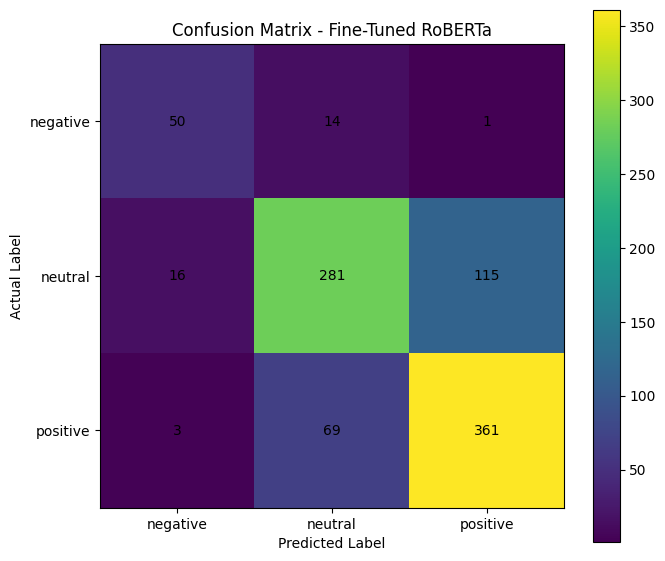

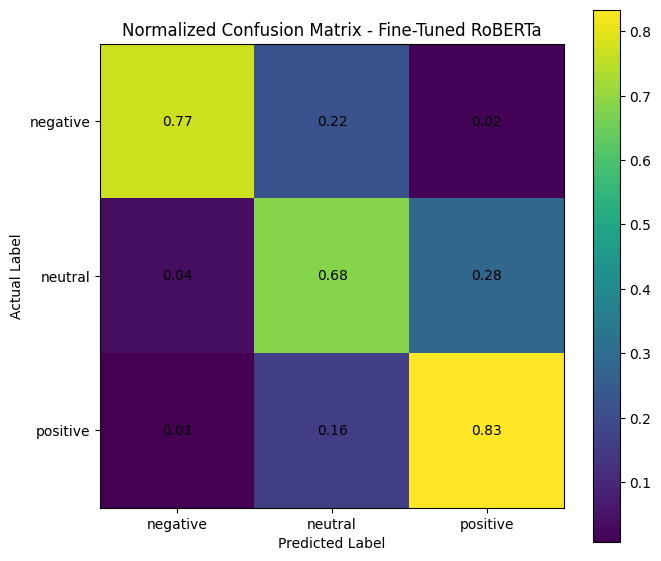


Saved files:
out_roberta/roberta_overall_metrics.csv
out_roberta/roberta_per_class_metrics.csv
out_roberta/roberta_classification_report.csv
out_roberta/roberta_confusion_matrix.csv
out_roberta/roberta_confusion_matrix_normalized.csv
out_roberta/roberta_confusion_matrix.png
out_roberta/roberta_confusion_matrix_normalized.png
out_roberta/roberta_val_predictions.csv
out_roberta/roberta_misclassified_validation_examples.csv

Top 20 highest-confidence misclassified examples:


,sentence,label,true_label,pred_label,p_neg,p_neu,p_pos,confidence
234,"This afternoon, the MOA we are signing with th...",positive,positive,neutral,0.000928,0.995916,0.003156,0.995916
820,"In the process, you are fulfilling a key role ...",neutral,neutral,positive,0.000615,0.003539,0.995846,0.995846
584,I recall we had our first respondents' meeting...,positive,positive,neutral,0.001883,0.995202,0.002915,0.995202
430,This should exert a positive influence on the ...,neutral,neutral,positive,0.000641,0.004300,0.995059,0.995059
824,"For the period ending March this year, net inc...",neutral,neutral,positive,0.001843,0.003726,0.994431,0.994431
742,This brings up our total profit remittances to...,neutral,neutral,positive,0.001168,0.004959,0.993873,0.993873
662,"To all our guests, we thank you once again for...",neutral,neutral,positive,0.000652,0.005549,0.993800,0.993800
574,"In the process, it gained independence in form...",neutral,neutral,positive,0.000809,0.005645,0.993546,0.993546
537,"In many of our neighbors, one key reason why i...",neutral,neutral,negative,0.993397,0.005609,0.000994,0.993397
519,"In the balance of payments, a meaningful but o...",neutral,neutral,positive,0.001093,0.005954,0.992953,0.992953


In [ ]:
# VALIDATION METRICS + CONFUSION MATRICES FOR BEST SAVED ROBERTA MODEL

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)
import matplotlib.pyplot as plt

def compute_metrics_full(preds, labels, label_names):
    preds = np.asarray(preds)
    labels = np.asarray(labels)

    acc = accuracy_score(labels, preds)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    prec_class, rec_class, f1_class, support_class = precision_recall_fscore_support(
        labels,
        preds,
        labels=list(range(len(label_names))),
        average=None,
        zero_division=0
    )

    mcc = matthews_corrcoef(labels, preds)

    metrics = {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(prec_weighted),
        "recall_weighted": float(rec_weighted),
        "f1_weighted": float(f1_weighted),
        "mcc": float(mcc)
    }

    per_class_df = pd.DataFrame({
        "label": label_names,
        "precision": prec_class,
        "recall": rec_class,
        "f1_score": f1_class,
        "support": support_class
    })

    return metrics, per_class_df


def evaluate_model(model, data_loader, device, loss_fn, label_order):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating best saved RoBERTa model"):
            batch = {k: v.to(device) for k, v in batch.items()}

            out = model(**batch)
            loss = loss_fn(out.logits, batch["labels"])
            total_loss += loss.item()

            logits = out.logits.detach().cpu().numpy()
            probs = softmax_np(logits)
            preds = probs.argmax(axis=1)
            labels = batch["labels"].detach().cpu().numpy()

            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    avg_loss = total_loss / max(1, len(data_loader))

    metrics, per_class_df = compute_metrics_full(
        preds=all_preds,
        labels=all_labels,
        label_names=label_order
    )

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(len(label_order)))
    )

    cm_norm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(len(label_order))),
        normalize="true"
    )

    return {
        "val_loss": avg_loss,
        "metrics": metrics,
        "per_class_df": per_class_df,
        "confusion_matrix": cm,
        "confusion_matrix_normalized": cm_norm,
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
        "probs": np.array(all_probs)
    }


# Evaluate validation set only
results = evaluate_model(
    model=clf_mdl,
    data_loader=val_dl,
    device=device,
    loss_fn=loss_fn,
    label_order=LABEL_ORDER
)

# Print label mapping to verify class order
print("Label order used:")
print(LABEL_ORDER)

print("\nModel id2label:")
print(clf_mdl.config.id2label)

print("\nModel label2id:")
print(clf_mdl.config.label2id)

# Print overall metrics
print("\nValidation Loss:", round(results["val_loss"], 4))

print("\nOverall Metrics:")
for k, v in results["metrics"].items():
    print(f"{k}: {v:.4f}")

# Print per-class metrics
print("\nPer-Class Metrics:")
print(results["per_class_df"])

# Print classification report
print("\nClassification Report:\n")
print(
    classification_report(
        results["labels"],
        results["preds"],
        labels=list(range(len(LABEL_ORDER))),
        target_names=LABEL_ORDER,
        digits=4,
        zero_division=0
    )
)

# Raw confusion matrix as dataframe
cm_df = pd.DataFrame(
    results["confusion_matrix"],
    index=[f"Actual_{label}" for label in LABEL_ORDER],
    columns=[f"Predicted_{label}" for label in LABEL_ORDER]
)

print("\nConfusion Matrix")
print(cm_df)

# Normalized confusion matrix as dataframe
cm_norm_df = pd.DataFrame(
    results["confusion_matrix_normalized"],
    index=[f"Actual_{label}" for label in LABEL_ORDER],
    columns=[f"Predicted_{label}" for label in LABEL_ORDER]
)

print("\nNormalized Confusion Matrix")
print(cm_norm_df.round(4))

# Plot raw confusion matrix
plt.figure(figsize=(7, 6))
plt.imshow(results["confusion_matrix"])
plt.title("Confusion Matrix - Fine-Tuned RoBERTa")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)
plt.yticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)

for i in range(len(LABEL_ORDER)):
    for j in range(len(LABEL_ORDER)):
        plt.text(
            j,
            i,
            str(results["confusion_matrix"][i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

cm_img_out = os.path.join(OUT_DIR, "roberta_confusion_matrix.png")
plt.savefig(cm_img_out, dpi=300, bbox_inches="tight")
plt.show()

# Plot normalized confusion matrix
plt.figure(figsize=(7, 6))
plt.imshow(results["confusion_matrix_normalized"])
plt.title("Normalized Confusion Matrix - Fine-Tuned RoBERTa")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)
plt.yticks(ticks=np.arange(len(LABEL_ORDER)), labels=LABEL_ORDER)

for i in range(len(LABEL_ORDER)):
    for j in range(len(LABEL_ORDER)):
        plt.text(
            j,
            i,
            f"{results['confusion_matrix_normalized'][i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

cm_norm_img_out = os.path.join(OUT_DIR, "roberta_confusion_matrix_normalized.png")
plt.savefig(cm_norm_img_out, dpi=300, bbox_inches="tight")
plt.show()

# Save overall metrics
overall_metrics_df = pd.DataFrame([{
    "model": "RoBERTa",
    "val_loss": results["val_loss"],
    **results["metrics"]
}])

overall_metrics_out = os.path.join(OUT_DIR, "roberta_overall_metrics.csv")
overall_metrics_df.to_csv(overall_metrics_out, index=False)

# Save per-class metrics
per_class_out = os.path.join(OUT_DIR, "roberta_per_class_metrics.csv")
results["per_class_df"].to_csv(per_class_out, index=False)

# Save classification report
report_dict = classification_report(
    results["labels"],
    results["preds"],
    labels=list(range(len(LABEL_ORDER))),
    target_names=LABEL_ORDER,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_out = os.path.join(OUT_DIR, "roberta_classification_report.csv")
report_df.to_csv(report_out, index=True)

# Save confusion matrices
cm_out = os.path.join(OUT_DIR, "roberta_confusion_matrix.csv")
cm_df.to_csv(cm_out, index=True)

cm_norm_out = os.path.join(OUT_DIR, "roberta_confusion_matrix_normalized.csv")
cm_norm_df.to_csv(cm_norm_out, index=True)

# Save validation predictions
val_eval_df = val_df[[TEXT_COL_LABELED, LABEL_COL_LABELED]].reset_index(drop=True).copy()

val_eval_df["true_label_id"] = results["labels"]
val_eval_df["pred_label_id"] = results["preds"]

val_eval_df["true_label"] = [LABEL_ORDER[i] for i in results["labels"]]
val_eval_df["pred_label"] = [LABEL_ORDER[i] for i in results["preds"]]

val_eval_df["p_neg"] = results["probs"][:, 0]
val_eval_df["p_neu"] = results["probs"][:, 1]
val_eval_df["p_pos"] = results["probs"][:, 2]

val_eval_df["confidence"] = results["probs"].max(axis=1)
val_eval_df["correct"] = val_eval_df["true_label_id"] == val_eval_df["pred_label_id"]

val_predictions_out = os.path.join(OUT_DIR, "roberta_val_predictions.csv")
val_eval_df.to_csv(val_predictions_out, index=False)

# Save misclassified examples
misclassified_df = val_eval_df[val_eval_df["correct"] == False].copy()
misclassified_df = misclassified_df.sort_values("confidence", ascending=False)

misclassified_out = os.path.join(OUT_DIR, "roberta_misclassified_validation_examples.csv")
misclassified_df.to_csv(misclassified_out, index=False)

print("\nSaved files:")
print(overall_metrics_out)
print(per_class_out)
print(report_out)
print(cm_out)
print(cm_norm_out)
print(cm_img_out)
print(cm_norm_img_out)
print(val_predictions_out)
print(misclassified_out)

print("\nTop 20 highest-confidence misclassified examples:")
display(
    misclassified_df[
        [TEXT_COL_LABELED, LABEL_COL_LABELED, "true_label", "pred_label",
         "p_neg", "p_neu", "p_pos", "confidence"]
    ].head(20)
)

In [ ]:
# Load speeches
df = pd.read_csv(SPEECHES_CSV)
for c in [ID_COL_SPEECHES, DATE_COL_SPEECHES, TEXT_COL_SPEECHES]:
    if c not in df.columns:
        raise ValueError(f"Missing column '{c}' in {SPEECHES_CSV}.")

df[DATE_COL_SPEECHES] = pd.to_datetime(df[DATE_COL_SPEECHES], errors="coerce")
if df[DATE_COL_SPEECHES].isna().any():
    raise ValueError("Some dates could not be parsed. Fix your speeches CSV.")

# Sentence split
df_sent = (df
           .assign(_sents=lambda d: d[TEXT_COL_SPEECHES].fillna("").apply(sent_tokenize))
           .explode("_sents")
           .rename(columns={"_sents":"sentence"})
           .reset_index(drop=True))
df_sent["sentence"] = df_sent["sentence"].fillna("").str.strip()
df_sent = df_sent[df_sent["sentence"].str.len() > 0].copy()

sentences = df_sent["sentence"].tolist()
probs_all = np.zeros((len(sentences), len(LABEL_ORDER)), dtype=np.float32)

# Inference in batches
for i in tqdm(range(0, len(sentences), BATCH_SIZE_SCORE), desc="Scoring sentences"):
    batch = sentences[i:i+BATCH_SIZE_SCORE]
    enc = clf_tok(batch, padding=True, truncation=True, max_length=MAX_LENGTH_SCORE, return_tensors="pt")
    enc = {k: v.to(device) for k,v in enc.items()}
    with torch.no_grad():
        logits = clf_mdl(**enc).logits.detach().cpu().numpy()
    probs = softmax_np(logits)
    probs_all[i:i+len(batch)] = probs

# Map to p_neg, p_neu, p_pos in the fixed order
df_sent["p_neg"] = probs_all[:, 0]
df_sent["p_neu"] = probs_all[:, 1]
df_sent["p_pos"] = probs_all[:, 2]
df_sent["tone"] = df_sent["p_pos"] - df_sent["p_neg"]  # [-1, +1]
pred_idx = probs_all.argmax(axis=1)
df_sent["label"] = [LABEL_ORDER[i] for i in pred_idx]

# Save sentence-level scores
sent_out = os.path.join(OUT_DIR, "sentences_scored.csv")
df_sent[[ID_COL_SPEECHES, DATE_COL_SPEECHES, "sentence", "p_neg", "p_neu", "p_pos", "tone", "label"]].to_csv(sent_out, index=False)
sent_out


/tmp/ipykernel_1324/650134879.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[DATE_COL_SPEECHES] = pd.to_datetime(df[DATE_COL_SPEECHES], errors="coerce")
Scoring sentences: 100%|██████████| 1371/1371 [02:56<00:00,  7.78it/s]


'out_roberta/sentences_scored.csv'

In [ ]:
def share_over(x, thr=0.5): return (x > thr).mean()
def majority_label(x): return x.value_counts().idxmax() if len(x) else "neutral"

agg = (df_sent
       .groupby([ID_COL_SPEECHES, DATE_COL_SPEECHES], as_index=False)
       .agg(tone_mean=("tone","mean"),
            tone_median=("tone","median"),
            pos_share=("p_pos", share_over),
            neg_share=("p_neg", share_over),
            neu_share=("p_neu", share_over),
            n_sent=("sentence","count")))
maj = (df_sent
       .groupby([ID_COL_SPEECHES, DATE_COL_SPEECHES])["label"]
       .apply(majority_label)
       .reset_index(name="label_majority"))

speech_df = agg.merge(maj, on=[ID_COL_SPEECHES, DATE_COL_SPEECHES], how="left")
speech_out = os.path.join(OUT_DIR, "speeches_aggregated.csv")
speech_df.to_csv(speech_out, index=False)
speech_out, speech_df.head(10)


('out_roberta/speeches_aggregated.csv',
    index       Date  tone_mean  tone_median  pos_share  neg_share  neu_share  \
 0      0 2020-03-03   0.567396     0.860377   0.659794   0.092784   0.247423   
 1      1 2020-02-28   0.559529     0.740518   0.672000   0.064000   0.256000   
 2      2 2020-02-27   0.611232     0.884500   0.703125   0.078125   0.195312   
 3      3 2020-02-06   0.530275     0.844944   0.636364   0.090909   0.227273   
 4      4 2020-01-31   0.218426     0.136954   0.200000   0.000000   0.800000   
 5      5 2020-01-30   0.557688     0.764604   0.639535   0.046512   0.308140   
 6      6 2020-01-28   0.678963     0.896422   0.752066   0.024793   0.214876   
 7      7 2020-01-24   0.663083     0.889505   0.714286   0.042857   0.242857   
 8      8 2020-01-21   0.316559     0.141881   0.363636   0.060606   0.575758   
 9      9 2020-01-09   0.578543     0.858285   0.654412   0.058824   0.257353   
 
    n_sent label_majority  
 0      97       positive  
 1     125 

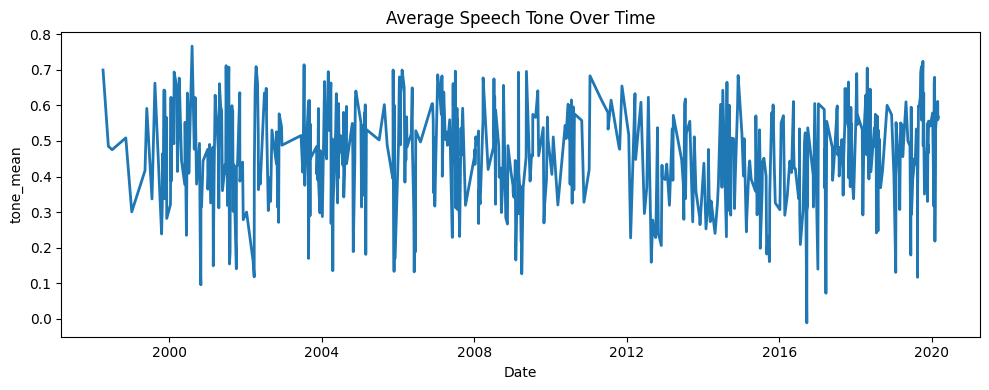

In [ ]:
import matplotlib.pyplot as plt

daily = (speech_df.groupby(DATE_COL_SPEECHES, as_index=False)["tone_mean"].mean().sort_values(DATE_COL_SPEECHES))
plt.figure(figsize=(10,4))
plt.plot(daily[DATE_COL_SPEECHES], daily["tone_mean"], linewidth=2)
plt.title("Average Speech Tone Over Time")
plt.xlabel("Date"); plt.ylabel("tone_mean"); plt.tight_layout(); plt.show()


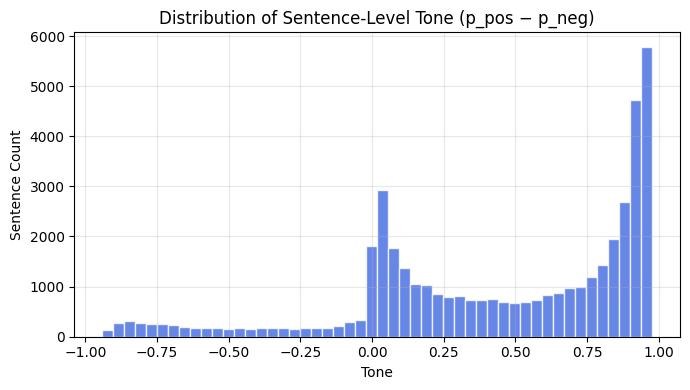

In [ ]:
# Load sentence-level results
df_sent = pd.read_csv("out_roberta/sentences_scored.csv")

plt.figure(figsize=(7,4))
plt.hist(df_sent["tone"], bins=50, color="royalblue", edgecolor="white", alpha=0.8)
plt.title("Distribution of Sentence-Level Tone (p_pos − p_neg)")
plt.xlabel("Tone")
plt.ylabel("Sentence Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

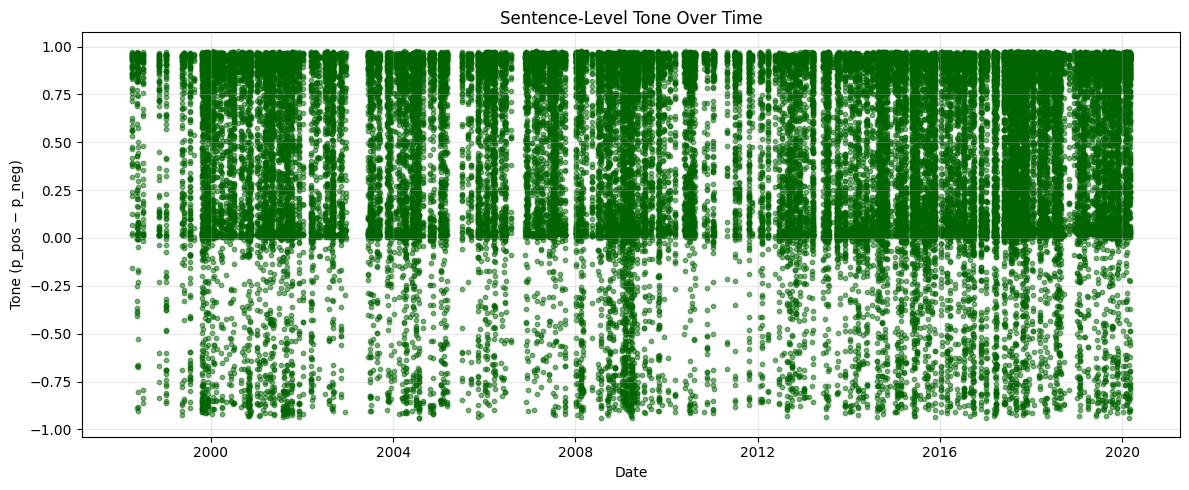

In [ ]:
df_sent["Date"] = pd.to_datetime(df_sent["Date"], errors="coerce")

plt.figure(figsize=(12,5))
plt.scatter(df_sent["Date"], df_sent["tone"], s=10, alpha=0.5, color="darkgreen")
plt.title("Sentence-Level Tone Over Time")
plt.xlabel("Date")
plt.ylabel("Tone (p_pos − p_neg)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

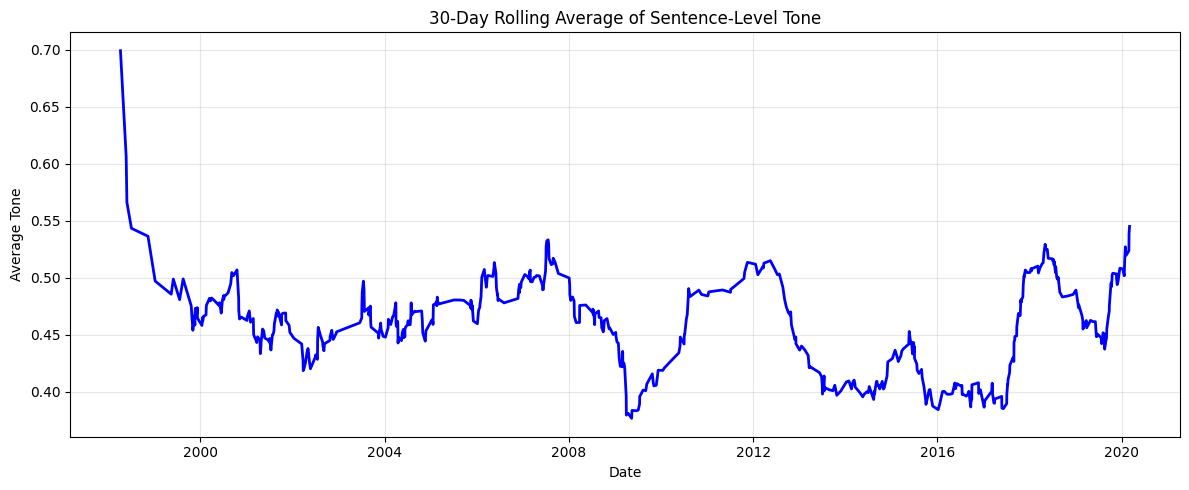

In [ ]:
# Rolling average (30-day window)
daily_mean = df_sent.groupby("Date")["tone"].mean().rolling(30, min_periods=1).mean()
plt.figure(figsize=(12,5))
plt.plot(daily_mean.index, daily_mean.values, color="blue", linewidth=2)
plt.title("30-Day Rolling Average of Sentence-Level Tone")
plt.xlabel("Date")
plt.ylabel("Average Tone")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

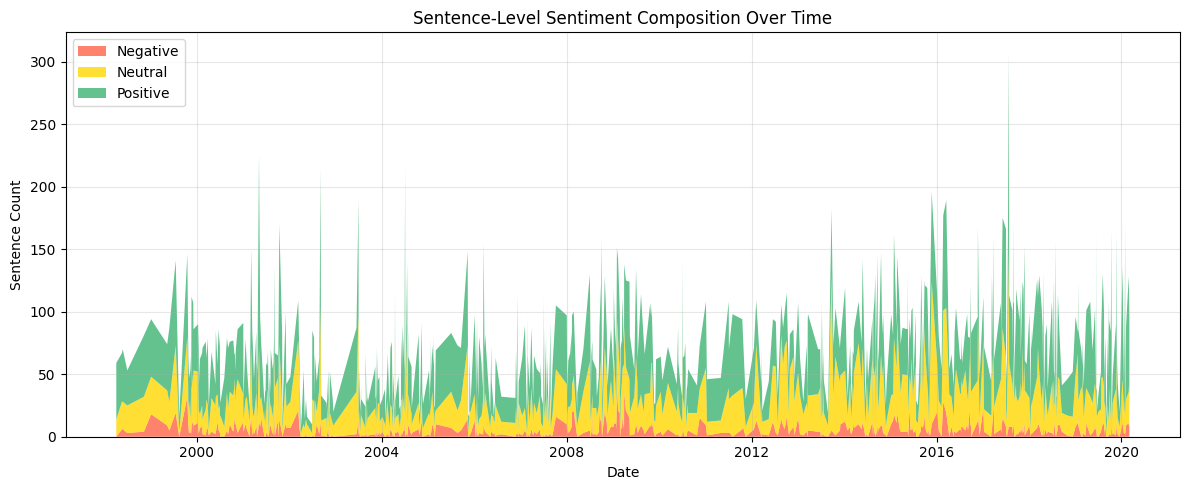

In [ ]:
label_counts = (
    df_sent.groupby(["Date", "label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plt.figure(figsize=(12,5))
plt.stackplot(
    label_counts.index,
    [label_counts["negative"], label_counts["neutral"], label_counts["positive"]],
    labels=["Negative","Neutral","Positive"],
    colors=["tomato","gold","mediumseagreen"],
    alpha=0.8
)
plt.title("Sentence-Level Sentiment Composition Over Time")
plt.xlabel("Date")
plt.ylabel("Sentence Count")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

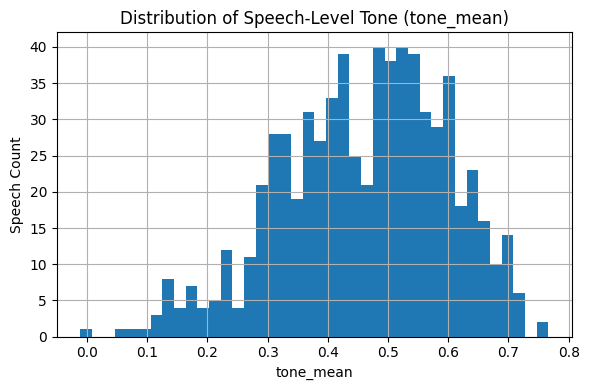

In [ ]:
plt.figure(figsize=(6,4))
speech_df["tone_mean"].hist(bins=40)
plt.title("Distribution of Speech-Level Tone (tone_mean)")
plt.xlabel("Tone Score"); plt.ylabel("Speech Count")
plt.tight_layout(); plt.show()